# Spiral → ConvNet Visualization Notebook

This notebook builds a tiny ConvNet that downsamples a spiral image from 64×64 to a final `(1, 64, 1, 1)` representation, and provides rich visualizations:

1. **Render ALL feature maps** at every layer (grid layout).
2. **Visualize kernels** of each `Conv2d` (mean over input channels, plus per-input-channel grids on demand).
3. **Explain/visualize the final 64-D vector** (bars, sorted bars with cumulative contribution, heatmap), and show how each final scalar arises from the previous spatial map + kernel.

Run cells top-to-bottom. No external libraries beyond PyTorch, NumPy, Matplotlib.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print(torch.__version__)

2.3.1


## Helpers: Feature map and kernel visualizations

In [2]:
def show_all_feature_maps(tensor, title="", max_cols=8):
    """
    Render all C channels (from the first item in the batch) as a grid.
    tensor: (B, C, H, W)
    """
    assert tensor.dim() == 4 and tensor.shape[0] >= 1
    C, H, W = tensor.shape[1], tensor.shape[2], tensor.shape[3]
    cols = min(max_cols, C)
    rows = math.ceil(C / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    if rows*cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    with torch.no_grad():
        for i in range(C):
            fmap = tensor[0, i].detach().cpu().numpy()
            axes[i].imshow(fmap, cmap='gray')
            axes[i].set_title(f"ch {i}  ({H}x{W})")
            axes[i].axis('off')

        for i in range(C, len(axes)):
            axes[i].axis('off')

    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_conv_kernels_mean_in(conv, title="", max_cols=8):
    """Show one image per OUT channel by averaging over IN channels.
    conv.weight: (C_out, C_in, kH, kW)
    """
    W = conv.weight.detach().cpu()
    C_out, C_in, kH, kW = W.shape
    kernels = W.mean(dim=1)  # (C_out, kH, kW)

    cols = min(max_cols, C_out)
    rows = math.ceil(C_out / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))
    if rows*cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i in range(C_out):
        axes[i].imshow(kernels[i], cmap='gray')
        axes[i].set_title(f"out {i}")
        axes[i].axis('off')
    for i in range(C_out, len(axes)):
        axes[i].axis('off')

    cap = f" (mean over in; k={kH}x{kW})" if kH==kW else f" (k={kH}x{kW})"
    if title:
        plt.suptitle(title + cap)
    else:
        plt.suptitle("Kernels" + cap)
    plt.tight_layout()
    plt.show()


def show_conv_kernels_full_grid(conv, out_idx=0, max_cols=8):
    """For a chosen output channel, show all input-channel slices as a grid."""
    W = conv.weight.detach().cpu()
    C_out, C_in, kH, kW = W.shape
    out_idx = int(max(0, min(out_idx, C_out-1)))

    cols = min(max_cols, C_in)
    rows = math.ceil(C_in / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    if rows*cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i in range(C_in):
        axes[i].imshow(W[out_idx, i].numpy(), cmap='gray')
        axes[i].set_title(f"in {i}")
        axes[i].axis('off')
    for i in range(C_in, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f"Kernels for out {out_idx} (k={kH}x{kW})")
    plt.tight_layout()
    plt.show()


def show_vector_bars(vec_1xC, title="Vector (bars)"):
    import numpy as _np
    v = vec_1xC.detach().cpu().view(-1).numpy()
    plt.figure(figsize=(10, 4))
    plt.bar(_np.arange(len(v)), v)
    plt.xlabel("Dimension (channel index)")
    plt.ylabel("Activation")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def show_sorted_vector_with_cumsum(vec_1xC, frac_line=0.9):
    import numpy as _np
    v = vec_1xC.detach().cpu().view(-1).numpy()
    idx = _np.argsort(-_np.abs(v))
    v_sorted = v[idx]
    cum = _np.cumsum(_np.abs(v_sorted)) / (_np.sum(_np.abs(v_sorted)) + 1e-8)

    plt.figure(figsize=(10, 4))
    plt.bar(_np.arange(len(v_sorted)), v_sorted)
    plt.title("Sorted activations (by |value|)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(cum, marker='o')
    plt.axhline(frac_line, linestyle='--')
    plt.xlabel("Top-k dimensions")
    plt.ylabel("Cumulative |activation|")
    plt.title("Cumulative contribution")
    plt.tight_layout()
    plt.show()


def show_vector_heatmap(vec_1xC, title="Vector heatmap"):
    v = vec_1xC.detach().cpu().view(1, -1).numpy()
    plt.figure(figsize=(10, 1.5))
    plt.imshow(v, aspect='auto', cmap='magma')
    plt.yticks([])
    plt.xlabel("Dimension")
    plt.title(title)
    plt.colorbar(shrink=0.7)
    plt.tight_layout()
    plt.show()


def explain_last_step(prev_tensor, last_conv, ch_idx=0):
    """
    Link one final scalar to its inputs.
    prev_tensor: (1, C_in, H, W) input to last_conv
    last_conv: Conv2d producing (1, C_out, 1, 1)
    ch_idx: which output channel to explain
    """
    with torch.no_grad():
        out = last_conv(prev_tensor)
        scalar = out[0, ch_idx, 0, 0].item()

    W = last_conv.weight.detach().cpu()[ch_idx]   # (C_in, kH, kW)
    b = last_conv.bias.detach().cpu()[ch_idx].item() if last_conv.bias is not None else 0.0
    W_mean = W.mean(dim=0).numpy()  # (kH, kW) for display only

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1)
    avg_map = prev_tensor[0].mean(dim=0).detach().cpu().numpy()
    plt.imshow(avg_map, cmap='gray')
    plt.title("Prev feature (avg over ch)")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(W_mean, cmap='gray')
    plt.title("Final kernel (mean over in)")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.text(0.5, 0.5, f"Scalar = {scalar:.3f}\n(+ bias {b:.3f})",
             ha='center', va='center', fontsize=12)
    plt.axis('off')
    plt.suptitle(f"How final channel {ch_idx} is formed")
    plt.tight_layout()
    plt.show()

## Spiral image and Conv stack (to 1×1 spatial, 64 channels)

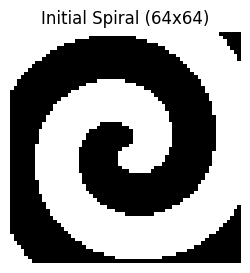

Sequential(
  (0): Conv2d(1, 2, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): Conv2d(2, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
)

In [3]:
def create_spiral_image(size=64):
    x = np.linspace(-2, 2, size)
    y = np.linspace(-2, 2, size)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(4 * np.sqrt(X**2 + Y**2) + np.arctan2(Y, X))
    return (Z > 0).astype(float)

size = 64  # must be power of 2 for pure stride-2 halving
spiral_image = create_spiral_image(size=size)
input_tensor = torch.tensor(spiral_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

plt.figure(figsize=(3,3))
plt.imshow(spiral_image, cmap='gray')
plt.title(f"Initial Spiral ({size}x{size})")
plt.axis('off')
plt.show()

target_channels = 64
n_down = int(math.log2(size))
assert 2**n_down == size, "Input size must be power of 2 for pure stride-2 halving."

conv_layers = []
current_channels = 1
for i in range(n_down):  # 6 layers for 64->1
    out_channels = min(current_channels * 2, target_channels)
    conv = nn.Conv2d(current_channels, out_channels, kernel_size=3, stride=2, padding=1)
    conv_layers.append(conv)
    current_channels = out_channels

model = nn.Sequential(*conv_layers)
model

## Forward pass with visualizations per layer

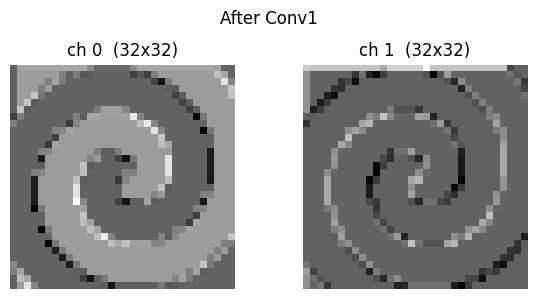

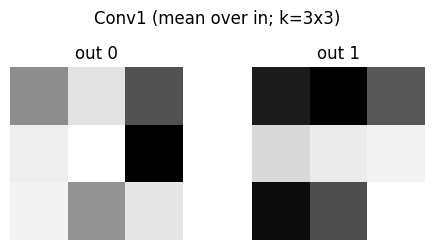

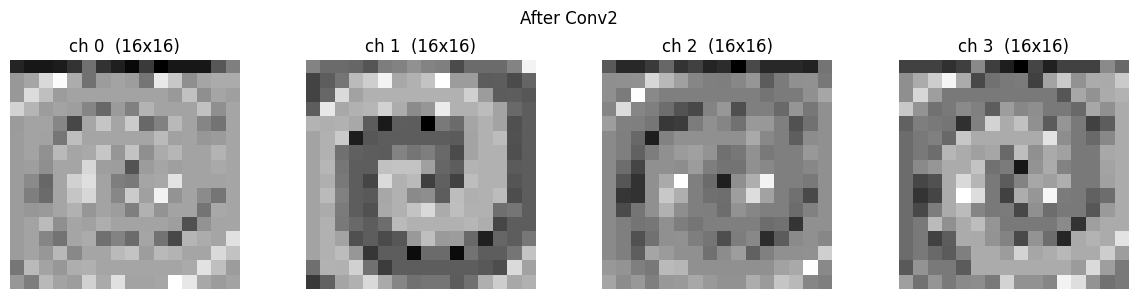

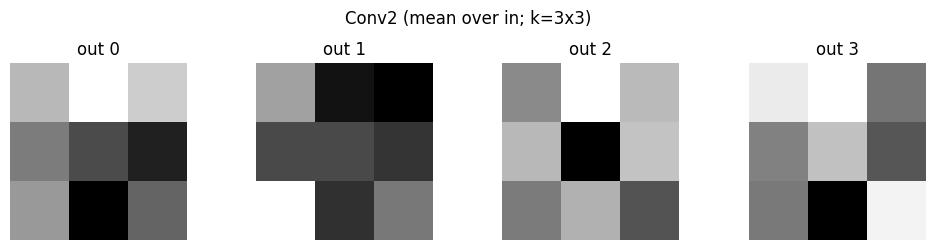

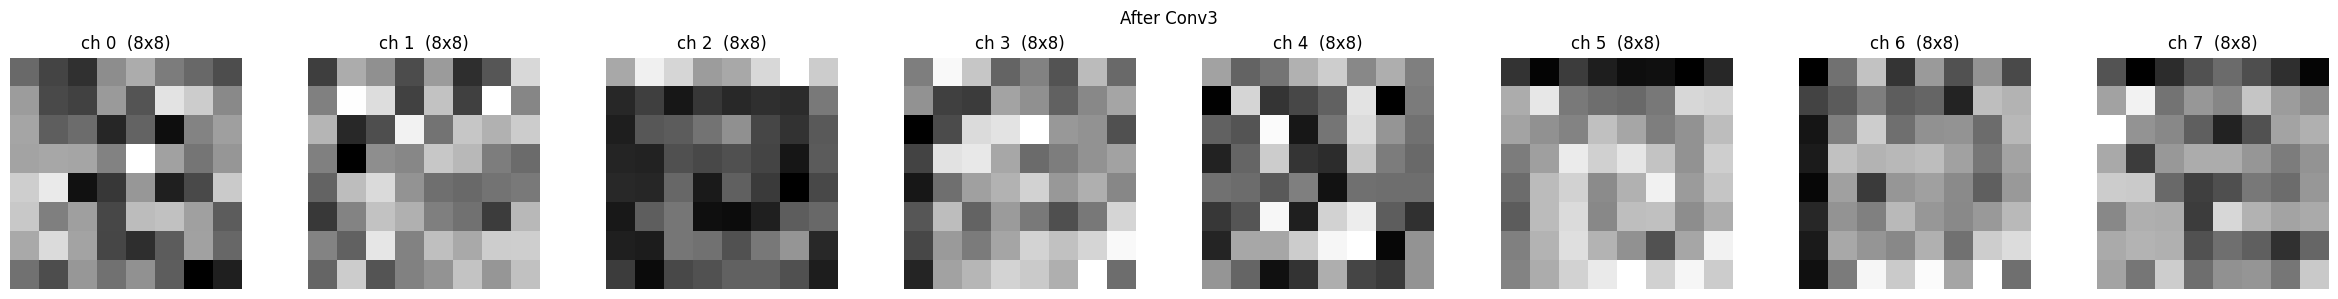

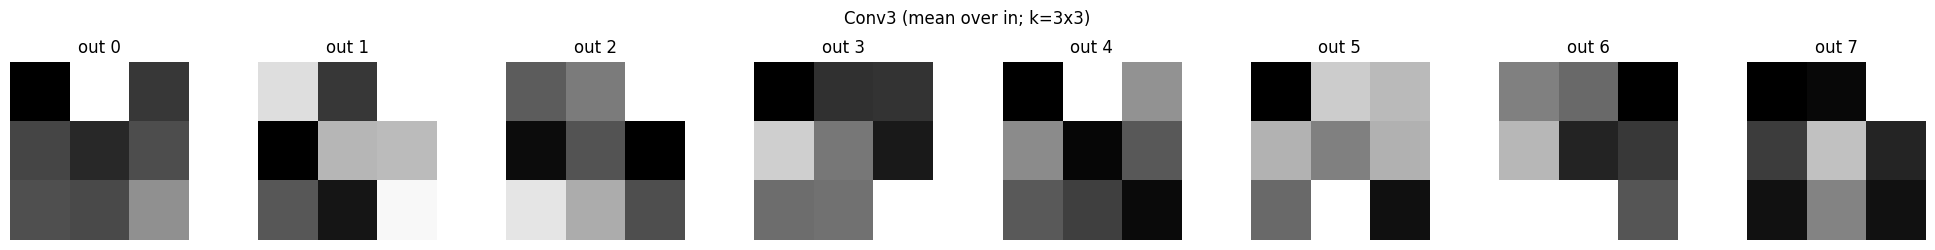

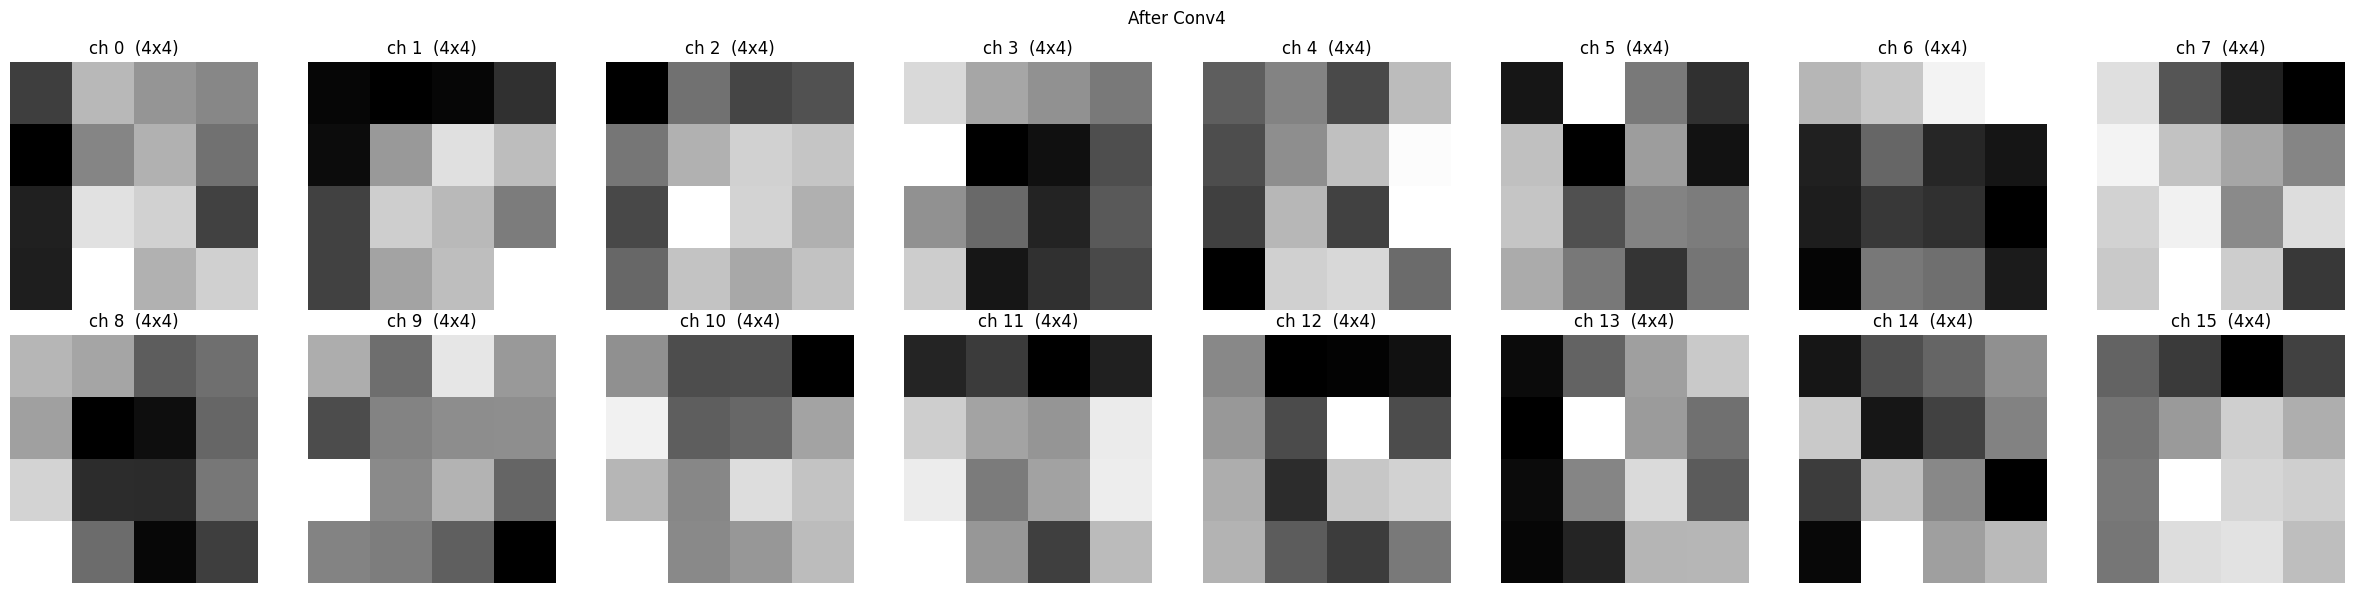

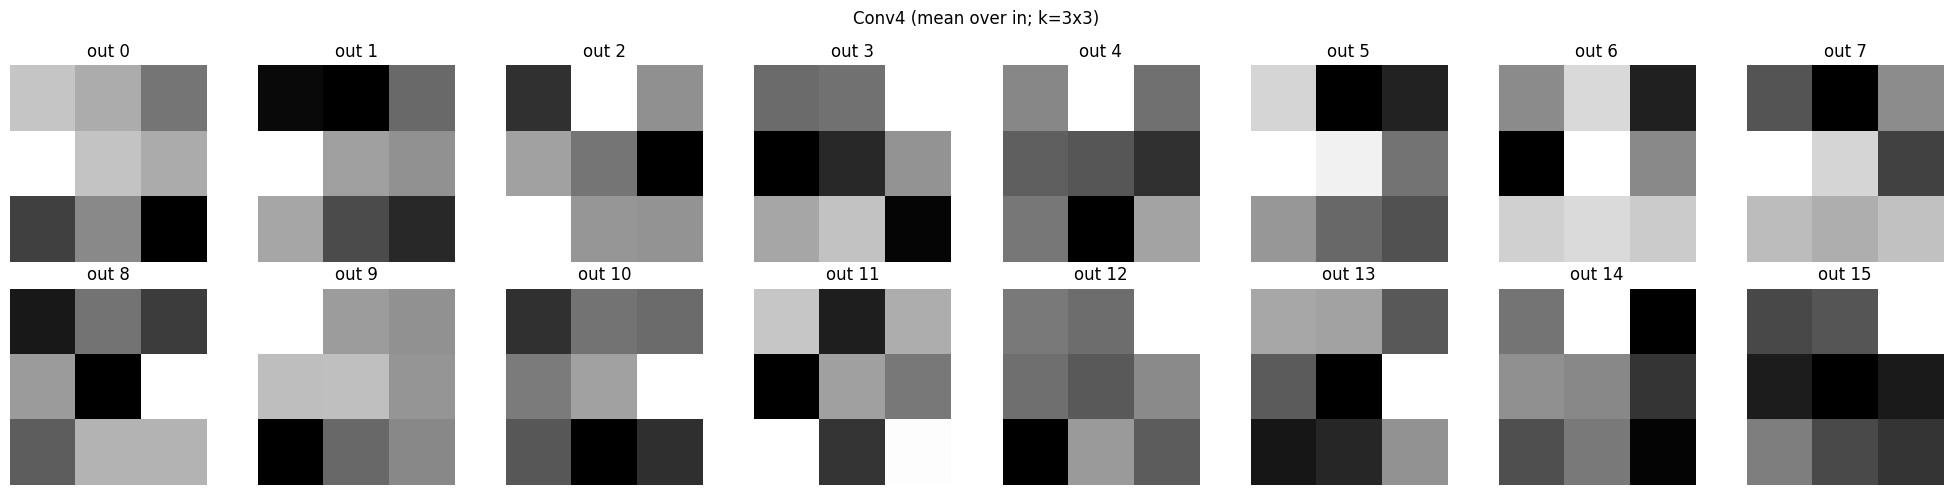

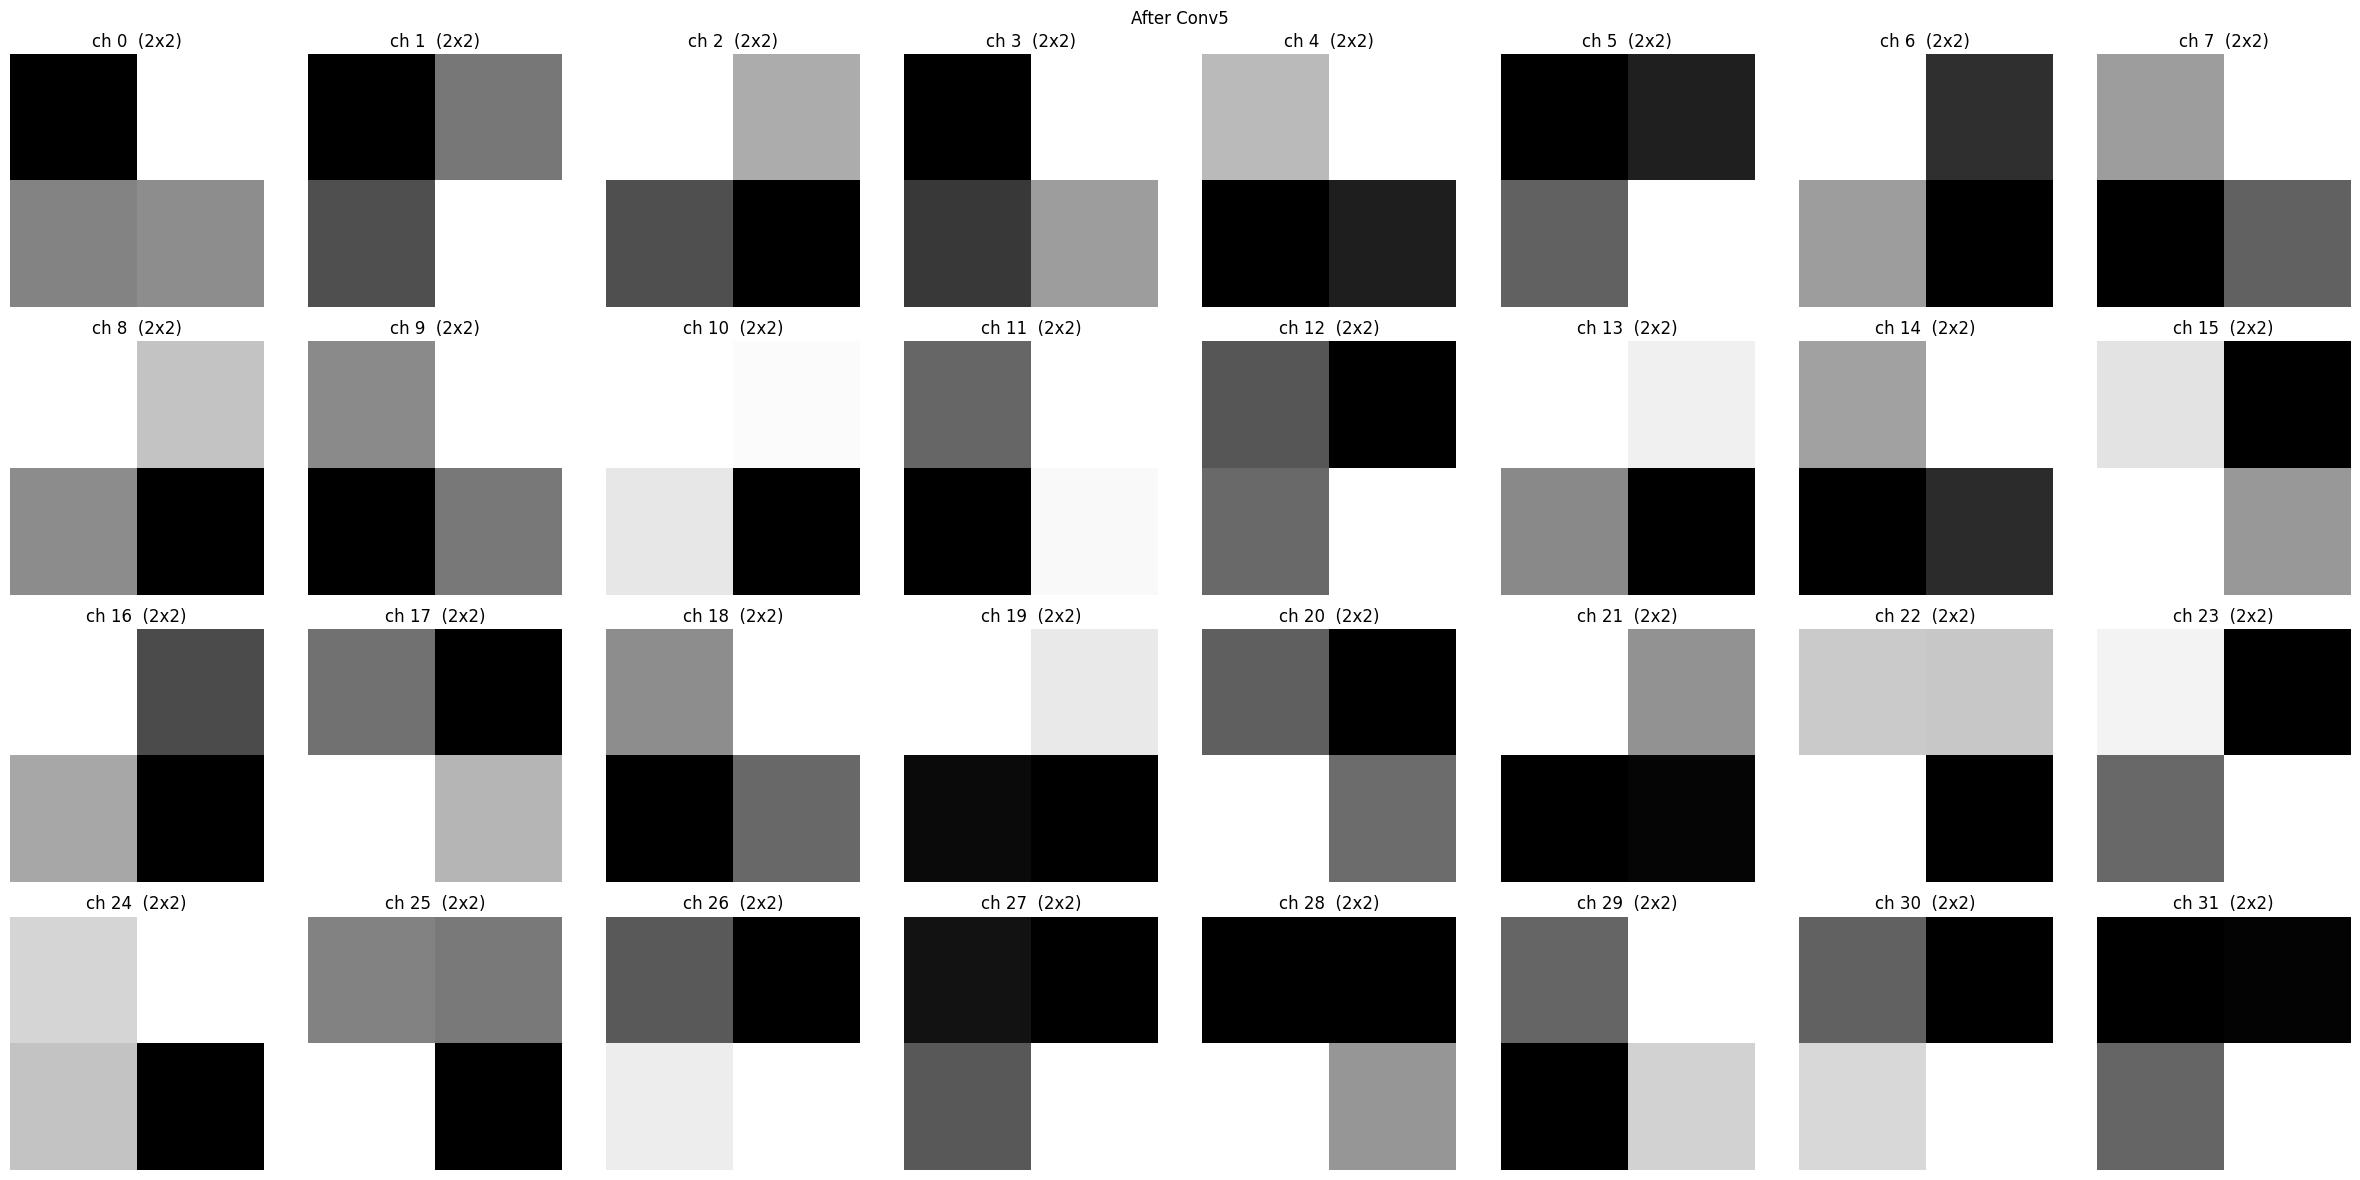

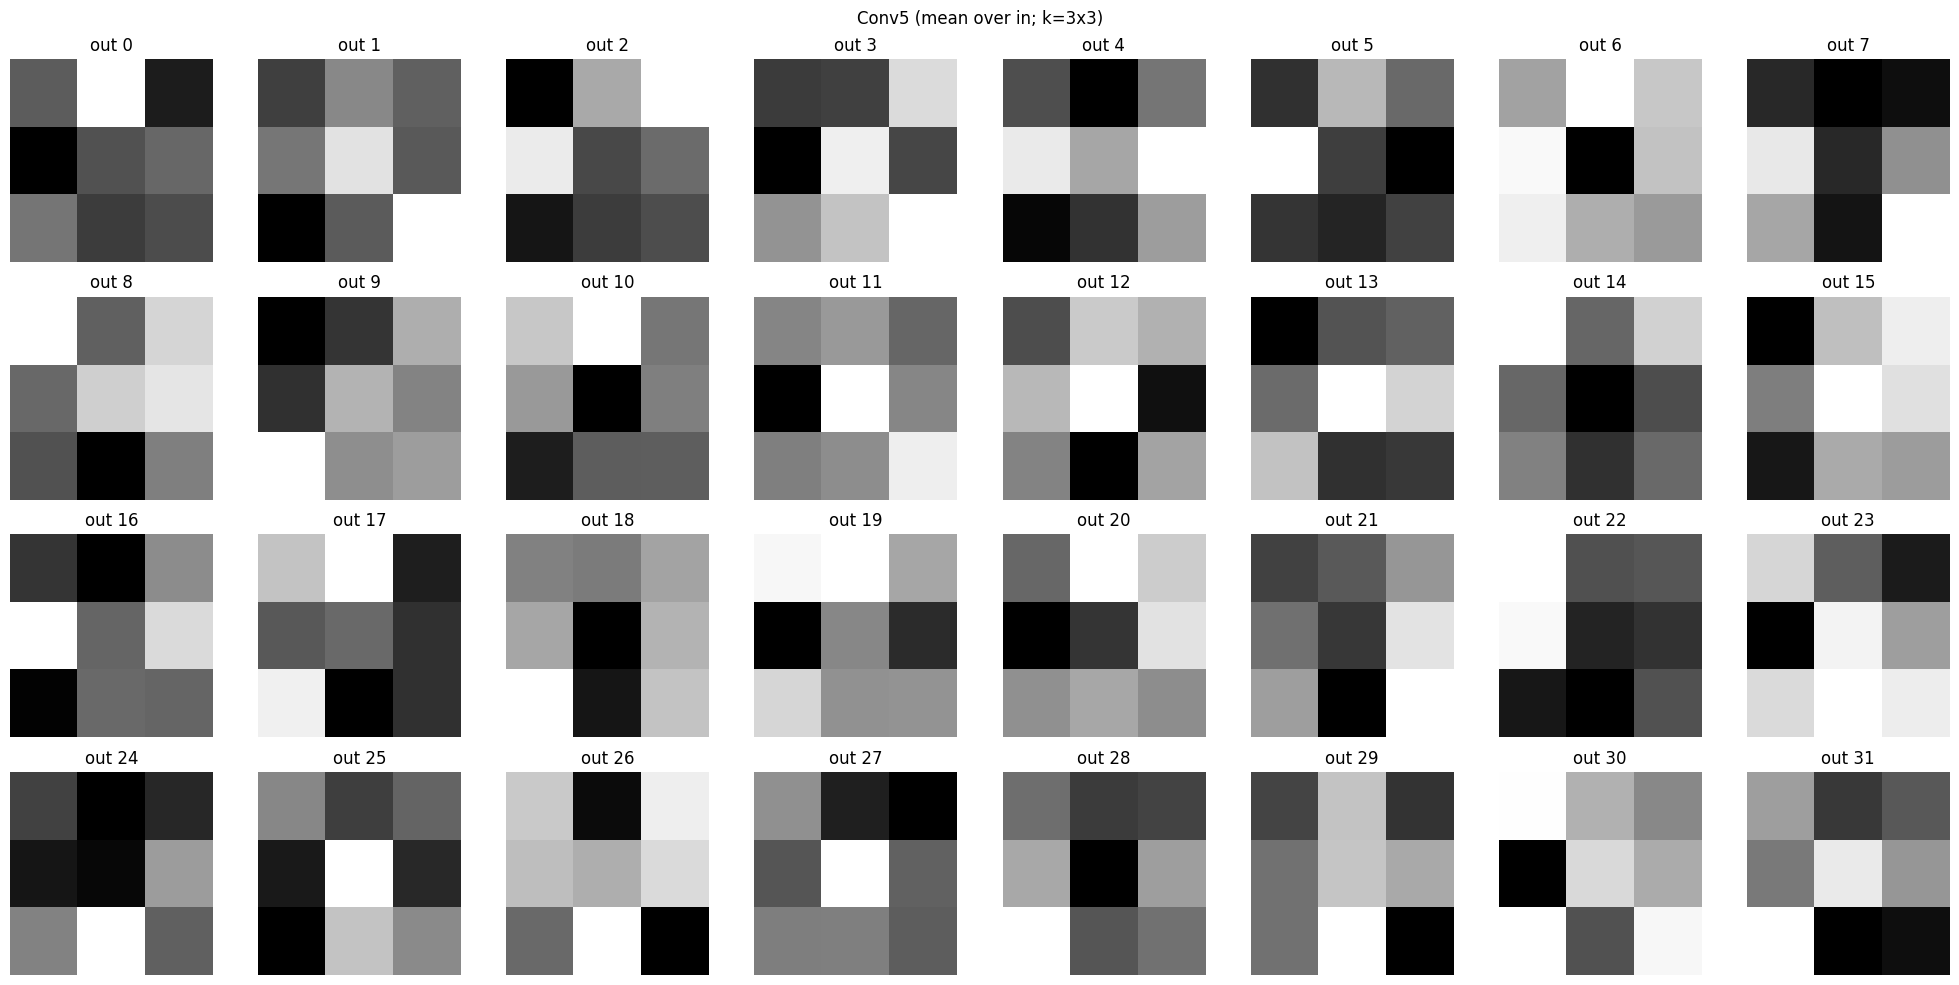

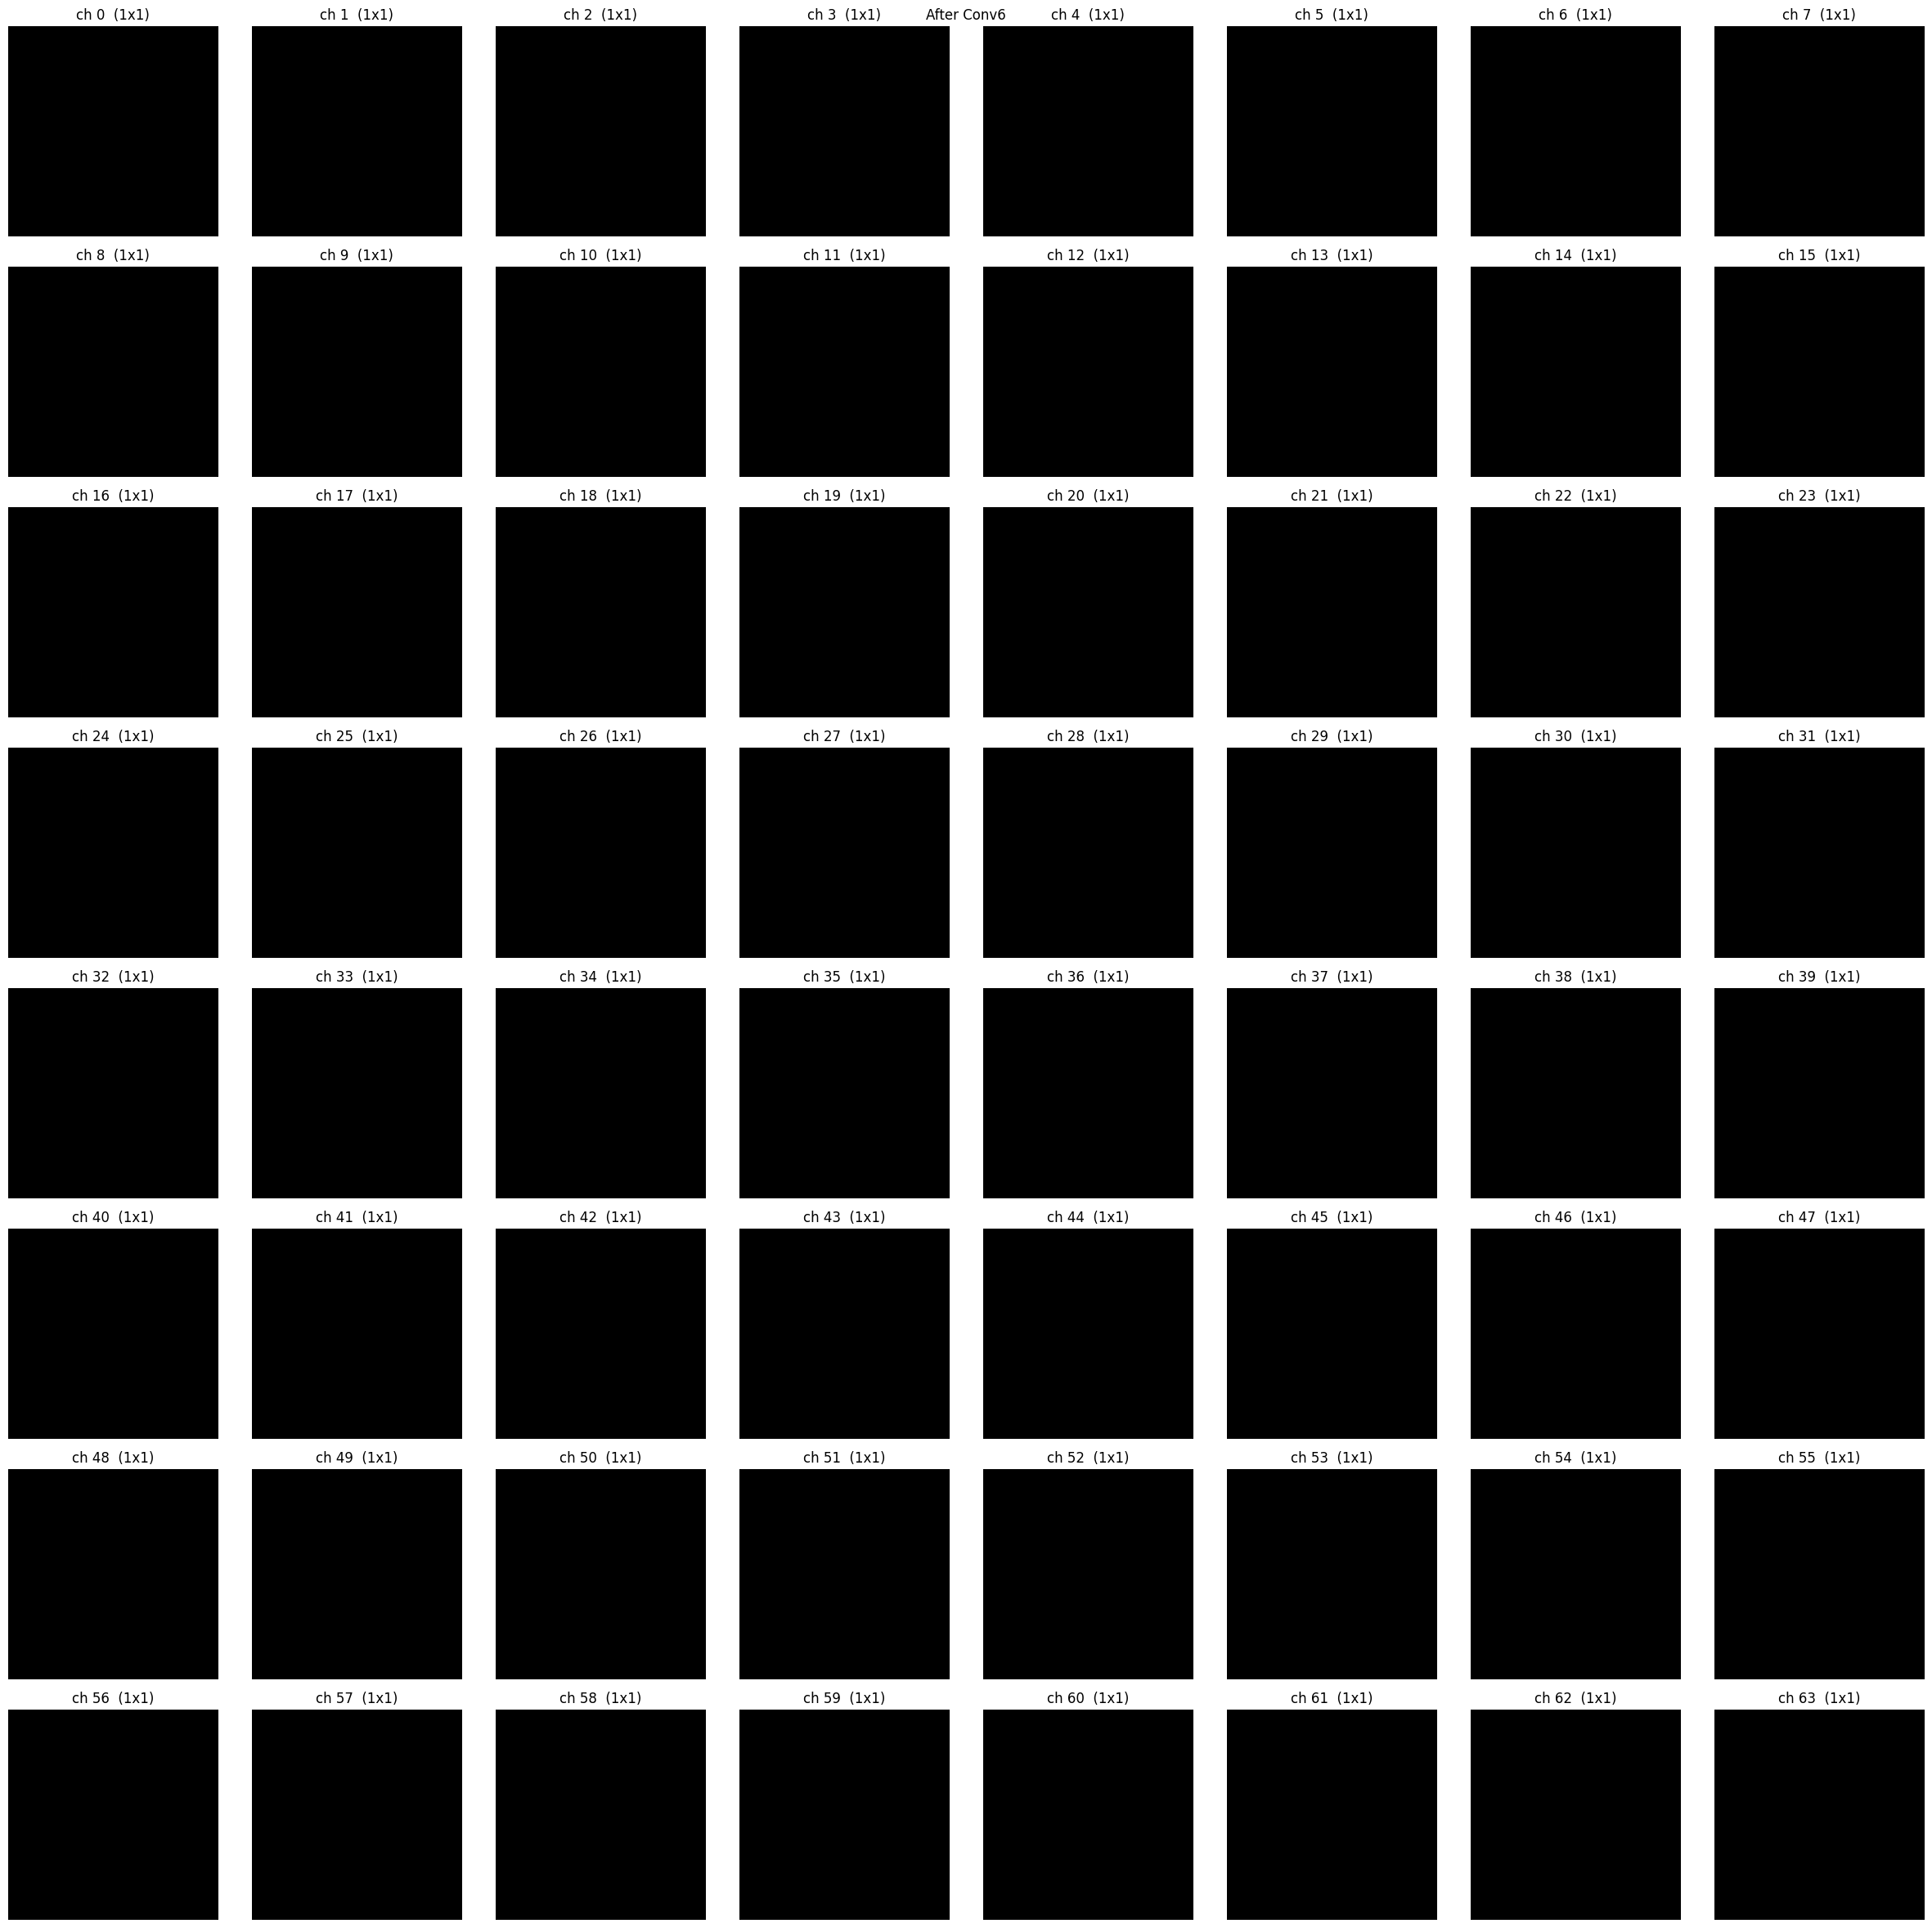

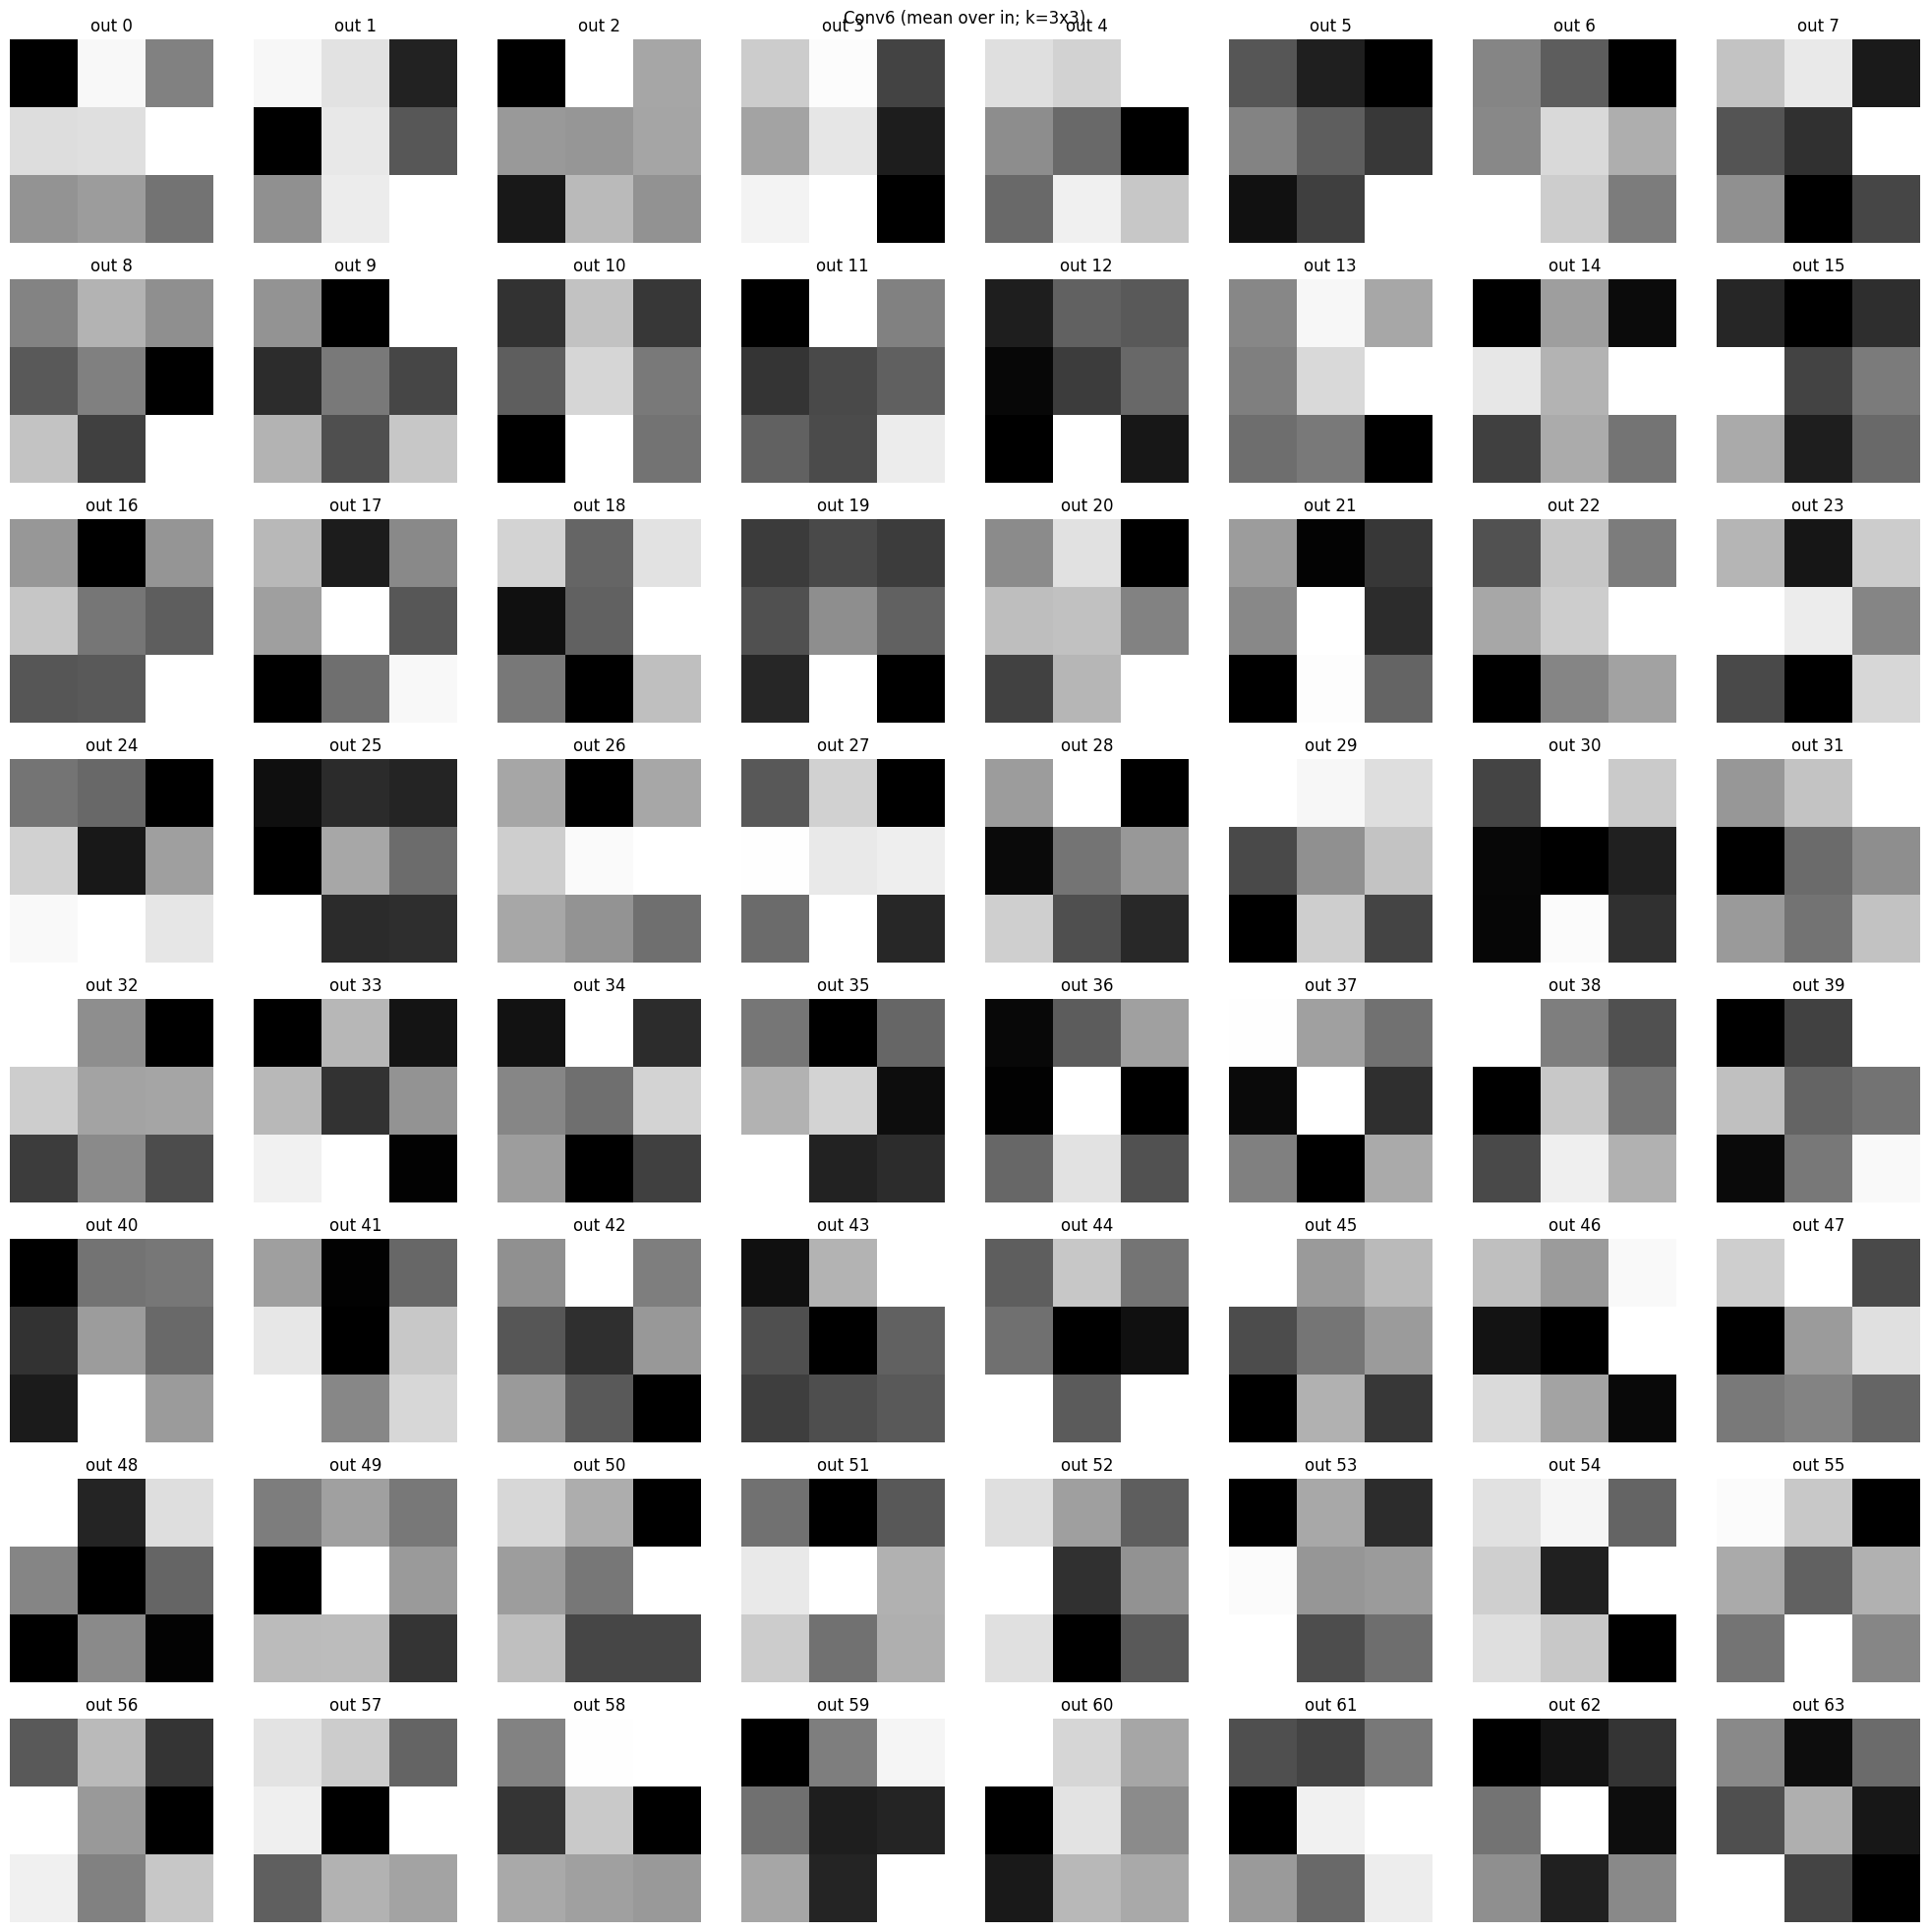

Final tensor shape: (1, 64, 1, 1)


In [4]:
current = input_tensor
intermediates = [input_tensor]
for idx, conv in enumerate(conv_layers, start=1):
    current = conv(current)
    intermediates.append(current)
    show_all_feature_maps(current, title=f"After Conv{idx}")
    show_conv_kernels_mean_in(conv, title=f"Conv{idx}")
    # Optional: drill into a single output channel's input slices
    # show_conv_kernels_full_grid(conv, out_idx=0)

print("Final tensor shape:", tuple(current.shape))

## Final 64-D representation visualizations

Vector shape: (1, 64)


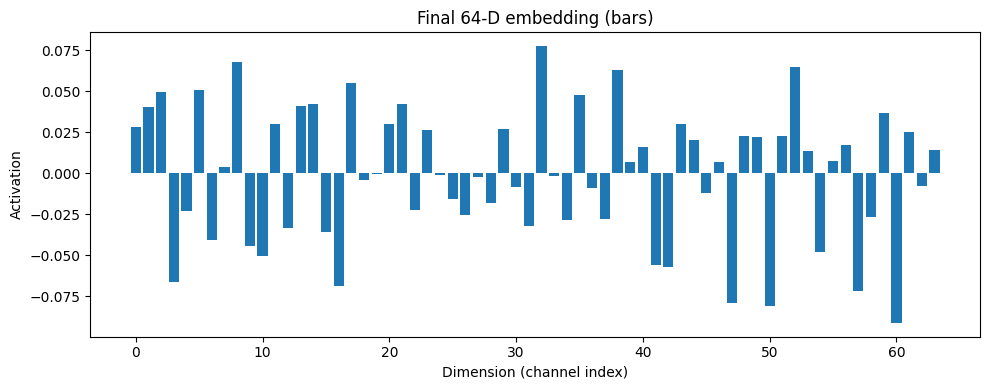

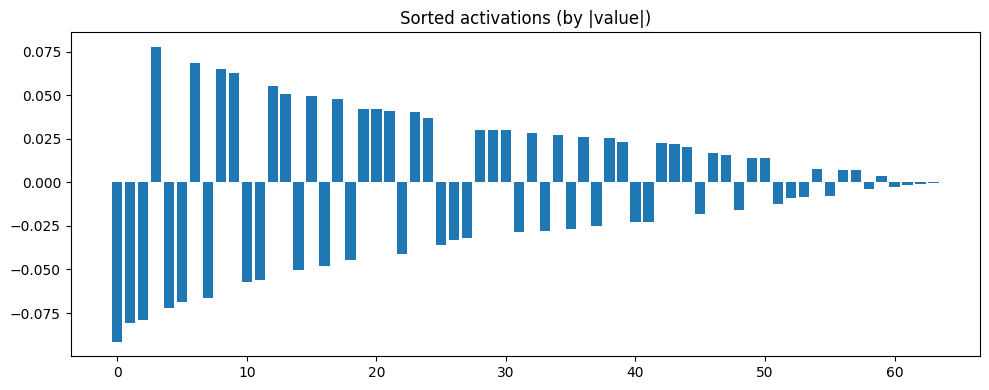

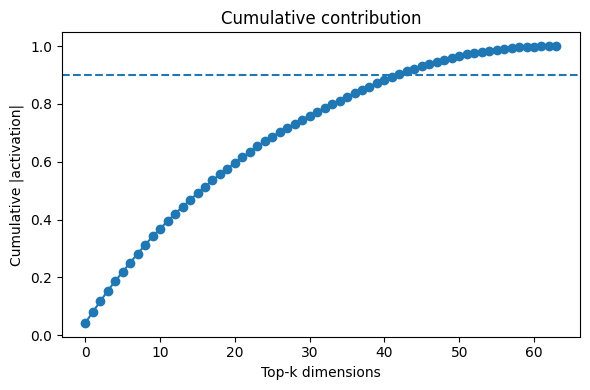

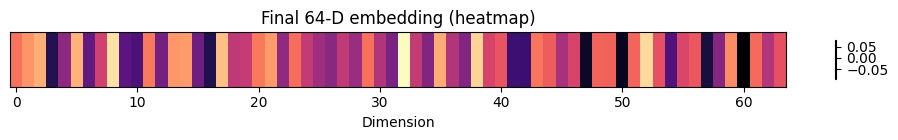

In [5]:
# Expect shape (1, 64, 1, 1)
final_vec = current.squeeze(-1).squeeze(-1)  # (1, 64)
print("Vector shape:", tuple(final_vec.shape))

show_vector_bars(final_vec, title="Final 64-D embedding (bars)")
show_sorted_vector_with_cumsum(final_vec)
show_vector_heatmap(final_vec, title="Final 64-D embedding (heatmap)")

## Explain one final scalar from the last step

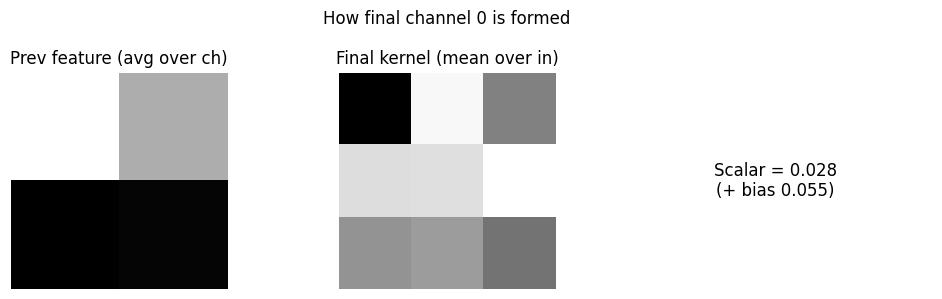

In [6]:
# Input to the last conv is the second-to-last intermediate
prev_to_last = intermediates[-2]
last_conv = conv_layers[-1]

explain_last_step(prev_to_last, last_conv, ch_idx=0)  # change ch_idx to explore others

### (Optional) Multiple inputs → 2-D projection
If you later want to compare many inputs, collect the final `(1,64)` vectors for each input and project with PCA/t-SNE for a scatter view. Not included by default to keep dependencies minimal.